In [1]:
import pandas as pd

outcome_df = pd.read_csv('../../Data/V4A.csv', usecols=['PublicID', 'V4AH01'], encoding='latin-1')
outcome_df['V4AH01'] = outcome_df['V4AH01'].replace('D', pd.NA)
outcome_df['V4AH01'] = pd.to_numeric(outcome_df['V4AH01'], errors='coerce')
outcome_df = outcome_df.drop_duplicates(subset=['PublicID'])
outcome_df['V4AH01'].value_counts() # 1 - breast feed only, 2 - bottle feed only, 3 - both

V4AH01
1.0    3042
3.0    1307
2.0     621
Name: count, dtype: int64

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))  # points to src/
from shared_modeling import (
    AdaptiveSMOTE,
    build_combined_feature_frame,
    create_pipeline,
    get_feature_names_from_pipeline,
    plot_confusion_matrix_for_model,
    plot_model_feature_importance,
    plot_permutation_importance_for_model,
    plot_roc_curve_for_model,
    plot_shap_summary_for_model,
    run_interpretability_suite,
    run_model_experiment,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from imblearn.pipeline import Pipeline as ImbPipeline  # Use imblearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import shap


/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
combined_inputs = build_combined_feature_frame(
    data_dir=Path('../../Data'),
    outcome_path='V4A.csv',
    outcome_column='V4AH01',
    outcome_encoding='latin-1',
    outcome_replace_map={'D': pd.NA},
    include_paternal=False,
    include_drugs=False,
    include_food=False,
    include_health_knowledge=False,
    include_mother_demo=False,
    include_physical_activity=False,
    include_sleep=False,
)
feature_lists = combined_inputs['feature_lists']
numeric_features = feature_lists['numeric_features']
categorical_features = feature_lists['categorical_features']
ordinal_features = feature_lists['ordinal_features']
binary_features = feature_lists['binary_features']
feature_columns = feature_lists['feature_columns']
combined_df = combined_inputs['combined_df']
outcome_df = combined_inputs['outcome_df']

split_frame = outcome_df[['PublicID', 'V4AH01']].dropna().drop_duplicates(subset=['PublicID'])
train_ids, test_ids = train_test_split(
    split_frame['PublicID'],
    test_size=0.2,
    random_state=42,
    stratify=split_frame['V4AH01'],
)

X = combined_df[feature_columns]
y = combined_df['V4AH01']
train_df = combined_df[combined_df['PublicID'].isin(train_ids)].copy()
test_df = combined_df[combined_df['PublicID'].isin(test_ids)].copy()
X_train = train_df.drop(['V4AH01', 'PublicID'], axis=1)
X_test = test_df.drop(['V4AH01', 'PublicID'], axis=1)
y_train = train_df['V4AH01']
y_test = test_df['V4AH01']
combined_df


,PublicID,oDM,ChronHTN,acog_PEgHTN,ResilienceTotalScore,ResilienceLevel,stress_average,FrequencyOfHassles,FrequencyOfUplifts,IntensityOfHassles,IntensityOfUplifts,HassleUpliftFrequencyRatio,HassleUpliftIntensityRatio,StressTotalScore,StressLevel,V4AH01
0,00004O,3.0,2.0,7.0,102.0,1.0,1.846154,10.0,10.0,2.6,3.0,1.0,0.866667,24.0,0.5,3.0
1,00007I,3.0,2.0,7.0,106.0,1.0,1.538462,10.0,10.0,2.0,2.6,1.0,0.769231,18.0,0.5,2.0
2,00008G,3.0,2.0,7.0,107.0,1.0,2.076923,10.0,10.0,2.2,2.4,1.0,0.916667,17.0,0.5,3.0
4,00017F,3.0,2.0,7.0,100.0,2.0,1.538462,10.0,10.0,1.9,2.7,1.0,0.703704,18.0,0.5,1.0
7,00023K,3.0,2.0,7.0,95.0,2.0,1.538462,10.0,10.0,1.5,2.6,1.0,0.576923,25.0,0.5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6655,17339L,3.0,2.0,7.0,122.0,1.0,1.923077,10.0,10.0,1.6,3.8,1.0,0.421053,8.0,0.0,1.0
6656,17340D,3.0,2.0,7.0,102.0,1.0,1.384615,10.0,10.0,1.6,3.9,1.0,0.410256,25.0,0.5,1.0
6657,17343U,3.0,2.0,7.0,96.0,2.0,1.666667,10.0,10.0,2.0,3.0,1.0,0.666667,13.0,0.0,1.0
6658,17345Q,3.0,2.0,7.0,122.0,1.0,1.692308,10.0,10.0,1.9,3.0,1.0,0.633333,11.0,0.0,1.0


In [4]:
# LR block using all domain features, with mother demographics split into numeric and categorical inputs.
lr_model, lr_pred, lr_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'lr',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)

Dropping rows with missing values because impute=False (train: 569, test: 140).
Final dataset sizes for LR (impute=False): train=3407, test=854
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model

Per-class metrics:
              precision    recall  f1-score   support

         1.0       0.67      0.50      0.57       538
         2.0       0.18      0.45      0.26        96
         3.0       0.31      0.30      0.30       220

    accuracy                           0.44       854
   macro avg       0.39      0.42      0.38       854
weighted avg       0.52      0.44      0.47       854

Best parameters found: {'classifier__C': 0.1, 'classifier__l1_ratio': 0.0}
Best CV Score (f1_macro): 0.3744
Model Coefficients:
num__ResilienceTotalScore: -0.0038715886619972513
num__stress_average: 0.09380932823141887
num__FrequencyOfHassles: -0.07172096489469444
num__FrequencyOfUplifts: -0.023586164498660123
num__IntensityOfHassles: 0.09401417642559319
num__IntensityOfUplifts: -0.07880439394674378
num__HassleUpliftFrequencyRatio: 0.05612940671579827
num__HassleUpliftIntensityRatio: -0.11469401423617631
num__StressTotalScore: -0.35182027091646
bin__ChronHTN: 0.6027211980688839
bin__Resilience

In [5]:
# RF block using all domain features, with mother demographics split into numeric and categorical inputs.
rf_model, rf_pred, rf_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'rf',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)

Dropping rows with missing values because impute=False (train: 569, test: 140).
Final dataset sizes for RF (impute=False): train=3407, test=854
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Per-class metrics:
              precision    recall  f1-score   support

         1.0       0.65      0.72      0.69       538
         2.0       0.21      0.18      0.19        96
         3.0       0.29      0.24      0.26       220

    accuracy                           0.54       854
   macro avg       0.38      0.38      0.38       854
weighted avg       0.51      0.54      0.52       854

Best parameters found: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 500}
Best CV Score (f1_macro): 0.3941
Feature Importances:
num__ResilienceTotalScore: 0.13076376790318175
num__stress_average: 0.11825378210386385
num__FrequencyOfHassles: 0.002172200378857631
num__FrequencyOfUplifts: 0.0007658783189962254
nu

In [6]:
# XGBoost block using all domain features, with mother demographics split into numeric and categorical inputs.
xgb_model, xgb_pred, xgb_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'xgb',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)

Dropping rows with missing values because impute=False (train: 569, test: 140).
Final dataset sizes for XGB (impute=False): train=3407, test=854
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Per-class metrics:
              precision    recall  f1-score   support

         1.0       0.65      0.75      0.70       538
         2.0       0.22      0.20      0.21        96
         3.0       0.31      0.21      0.25       220

    accuracy                           0.55       854
   macro avg       0.39      0.39      0.39       854
weighted avg       0.52      0.55      0.53       854

Best parameters found: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 4, 'classifier__n_estimators': 100, 'classifier__subsample': 0.5}
Best CV Score (f1_macro): 0.4042
Feature Importances:
num__ResilienceTotalScore: 0.035855043679475784
num__stress_average: 0.042090993374586105
num__FrequencyOfHassles: 0.04840122163295746
num__FrequencyO

In [7]:
# SVM block using all domain features, with mother demographics split into numeric and categorical inputs.
svm_model, svm_pred, svm_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'svm',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)

Dropping rows with missing values because impute=False (train: 569, test: 140).
Final dataset sizes for SVM (impute=False): train=3407, test=854
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Per-class metrics:
              precision    recall  f1-score   support

         1.0       0.67      0.54      0.60       538
         2.0       0.20      0.34      0.25        96
         3.0       0.30      0.34      0.32       220

    accuracy                           0.47       854
   macro avg       0.39      0.41      0.39       854
weighted avg       0.52      0.47      0.49       854

Best parameters found: {'classifier__estimator__C': 0.1, 'classifier__estimator__gamma': 0.01, 'classifier__estimator__kernel': 'rbf'}
Best CV Score (f1_macro): 0.3840
Skipping feature-level SVM output to keep notebook output compact.
Evaluation Metrics for SVM with shared preprocessing and adaptive CV scoring:
Accuracy: 0.4696
Precision: 0.3896
Recall: 0.4098
Macro F1: 0.3905
Weighted F1: 

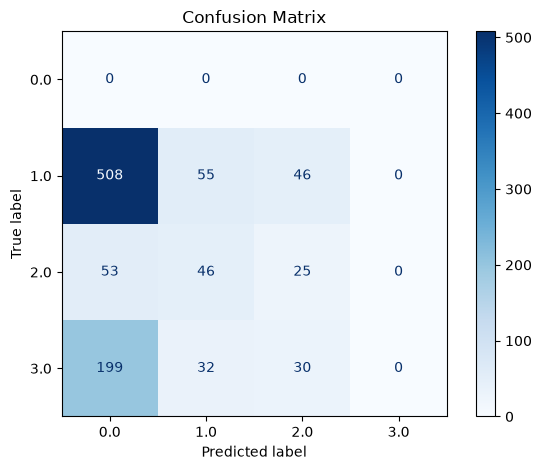

ROC curve skipped: multiclass targets are not plotted as a single ROC curve.


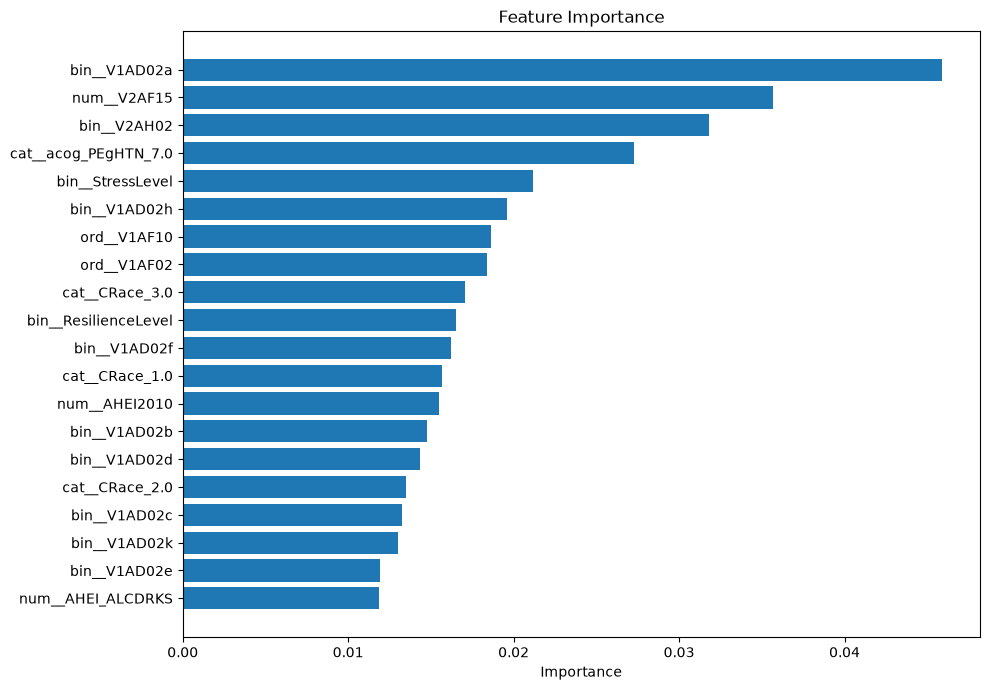

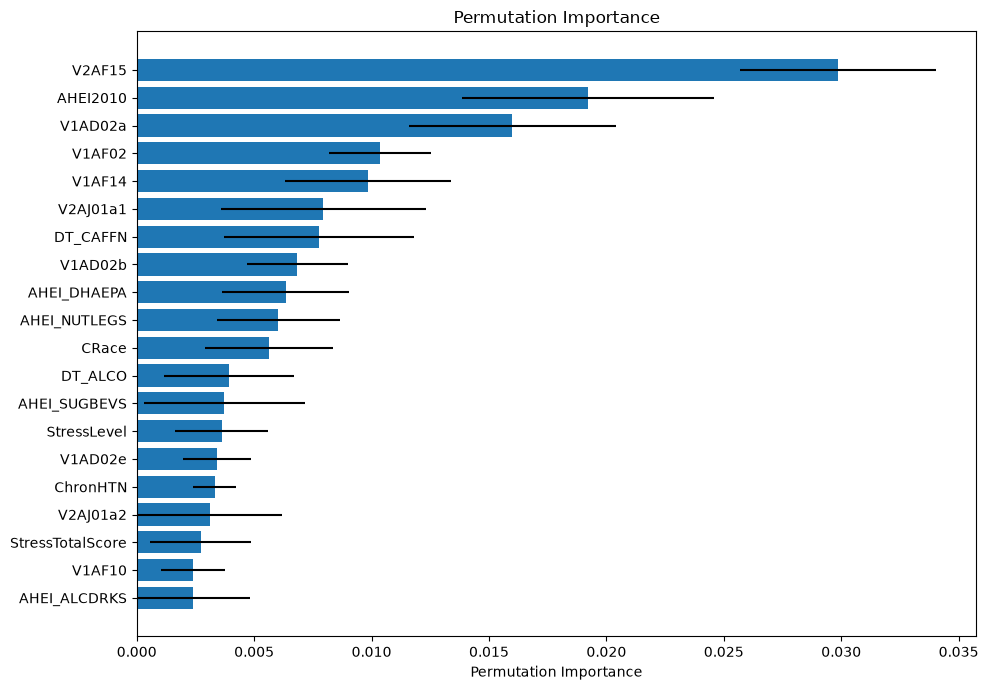

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP skipped: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.


In [16]:
# Interpretability for the XGB breastfeeding model.
# Swap xgb_model for lr_model, rf_model, or svm_model if you want a different view.
run_interpretability_suite(xgb_model, X_train, X_test, y_test, labels=[1, 2, 3], top_n=20)